# Kaggle Playground Series (S6E8) — Smartphone Addiction Prediction

## Overview
- **Objective:** Predict smartphone addiction (`addicted_label`) from behavioral and usage data.
- **Evaluation Metric:** ROC-AUC
- **Dataset:** `playground-series-s6e8` (~691k train, ~296k test)
- **Class Balance:** ~70.9% positive (`addicted_label = 1`), ~29.1% negative (`addicted_label = 0`)

---
## Pipeline Overview
1. **Environment Setup:** Imports, dependencies, and device configuration.
2. **Data Ingestion & EDA:** Data profiling, missing value distributions, and target relationships.
3. **Feature Engineering:**
   - Missing value indicators and total missing counts
   - Screen time ratios (social media, gaming, entertainment vs. work/study)
   - Notification and app open frequencies per hour
   - Weekend vs. weekday usage differences and sleep indicators
   - Group aggregations across demographic and behavioral segments
   - Ordinal and frequency encodings for categorical features
4. **Validation:** Stratified 5-fold cross-validation.
5. **Models:**
   - LightGBM Classifier
   - XGBoost Classifier
   - CatBoost Classifier
   - HistGradientBoostingClassifier
   - PyTorch Tabular ResNet
6. **Ensembling:** Weighted blending (ROC-AUC optimization) and logistic ridge stacking.
7. **Validation Diagnostics:** Out-of-fold ROC curves, confusion matrices, and feature importances.
8. **Inference & Submission:** Test set predictions and submission formatting.


In [1]:
# =============================================================================
# 1. ENVIRONMENT CONFIGURATION, IMPORTS & AUTO-INSTALLER
# =============================================================================
import os
import sys
import gc
import time
import math
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve, auc, log_loss
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from scipy.optimize import minimize

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")

# Auto-install missing gradient boosting libraries if needed
for pkg in ["lightgbm", "xgboost", "catboost", "optuna"]:
    try:
        __import__(pkg)
    except ImportError:
        print(f"[INFO] Installing {pkg}...")
        import subprocess
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg])

try:
    import lightgbm as lgb
    HAS_LGB = True
except ImportError:
    HAS_LGB = False
    print("[WARN] LightGBM not available. Will use HistGradientBoostingClassifier.")

try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("[WARN] XGBoost not available.")

try:
    import catboost as cb
    HAS_CB = True
except ImportError:
    HAS_CB = False
    print("[WARN] CatBoost not available.")

# Set Global Random Seed for Reproducibility
SEED = 42
def seed_everything(seed=42):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True

seed_everything(SEED)

# Device Setup
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ Hardware Device: {DEVICE} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'})")
print(f"✓ Packages: LightGBM={HAS_LGB}, XGBoost={HAS_XGB}, CatBoost={HAS_CB}, PyTorch={torch.__version__}")

✓ Hardware Device: cuda (NVIDIA GeForce RTX 3050 Laptop GPU)
✓ Packages: LightGBM=True, XGBoost=True, CatBoost=True, PyTorch=2.4.1+cu124


In [2]:
# =============================================================================
# 2. DATA INGESTION & FAST MEMORY OPTIMIZATION
# =============================================================================
DATA_DIR = Path("playground-series-s6e8") if Path("playground-series-s6e8").exists() else Path(".")
TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"
SAMPLE_SUB_PATH = DATA_DIR / "sample_submission.csv"

print(f"Loading data from: {DATA_DIR.resolve()}")
t0 = time.time()
df_train = pd.read_csv(TRAIN_PATH)
df_test = pd.read_csv(TEST_PATH)
df_sub = pd.read_csv(SAMPLE_SUB_PATH)
print(f"Loaded in {time.time()-t0:.2f}s.")

print(f"Train Shape: {df_train.shape} | Test Shape: {df_test.shape} | Sample Sub Shape: {df_sub.shape}")

# Memory Optimization Function
def reduce_mem_usage(df, verbose=True):
    start_mem = df.memory_usage().sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtype
        if col_type != object and str(col_type) != "category":
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == "int":
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
            else:
                df[col] = df[col].astype(np.float32)
    end_mem = df.memory_usage().sum() / 1024**2
    if verbose:
        print(f"Memory usage reduced: {start_mem:.2f} MB -> {end_mem:.2f} MB ({100 * (start_mem - end_mem) / start_mem:.1f}% reduction)")
    return df

df_train = reduce_mem_usage(df_train)
df_test = reduce_mem_usage(df_test)

# Inspect Target Distribution
target_counts = df_train["addicted_label"].value_counts()
target_pct = df_train["addicted_label"].value_counts(normalize=True) * 100
print("\n--- Target Class Distribution ---")
for val in [1, 0]:
    print(f"Class {val}: {target_counts[val]:,d} samples ({target_pct[val]:.2f}%)")

Loading data from: C:\programming\kaggle-comps\playground-series-s6e8\playground-series-s6e8
Loaded in 0.89s.
Train Shape: (691369, 14) | Test Shape: (296302, 13) | Sample Sub Shape: (296302, 2)
Memory usage reduced: 73.85 MB -> 42.86 MB (42.0% reduction)
Memory usage reduced: 29.39 MB -> 18.08 MB (38.5% reduction)

--- Target Class Distribution ---
Class 1: 490,474 samples (70.94%)
Class 0: 200,895 samples (29.06%)


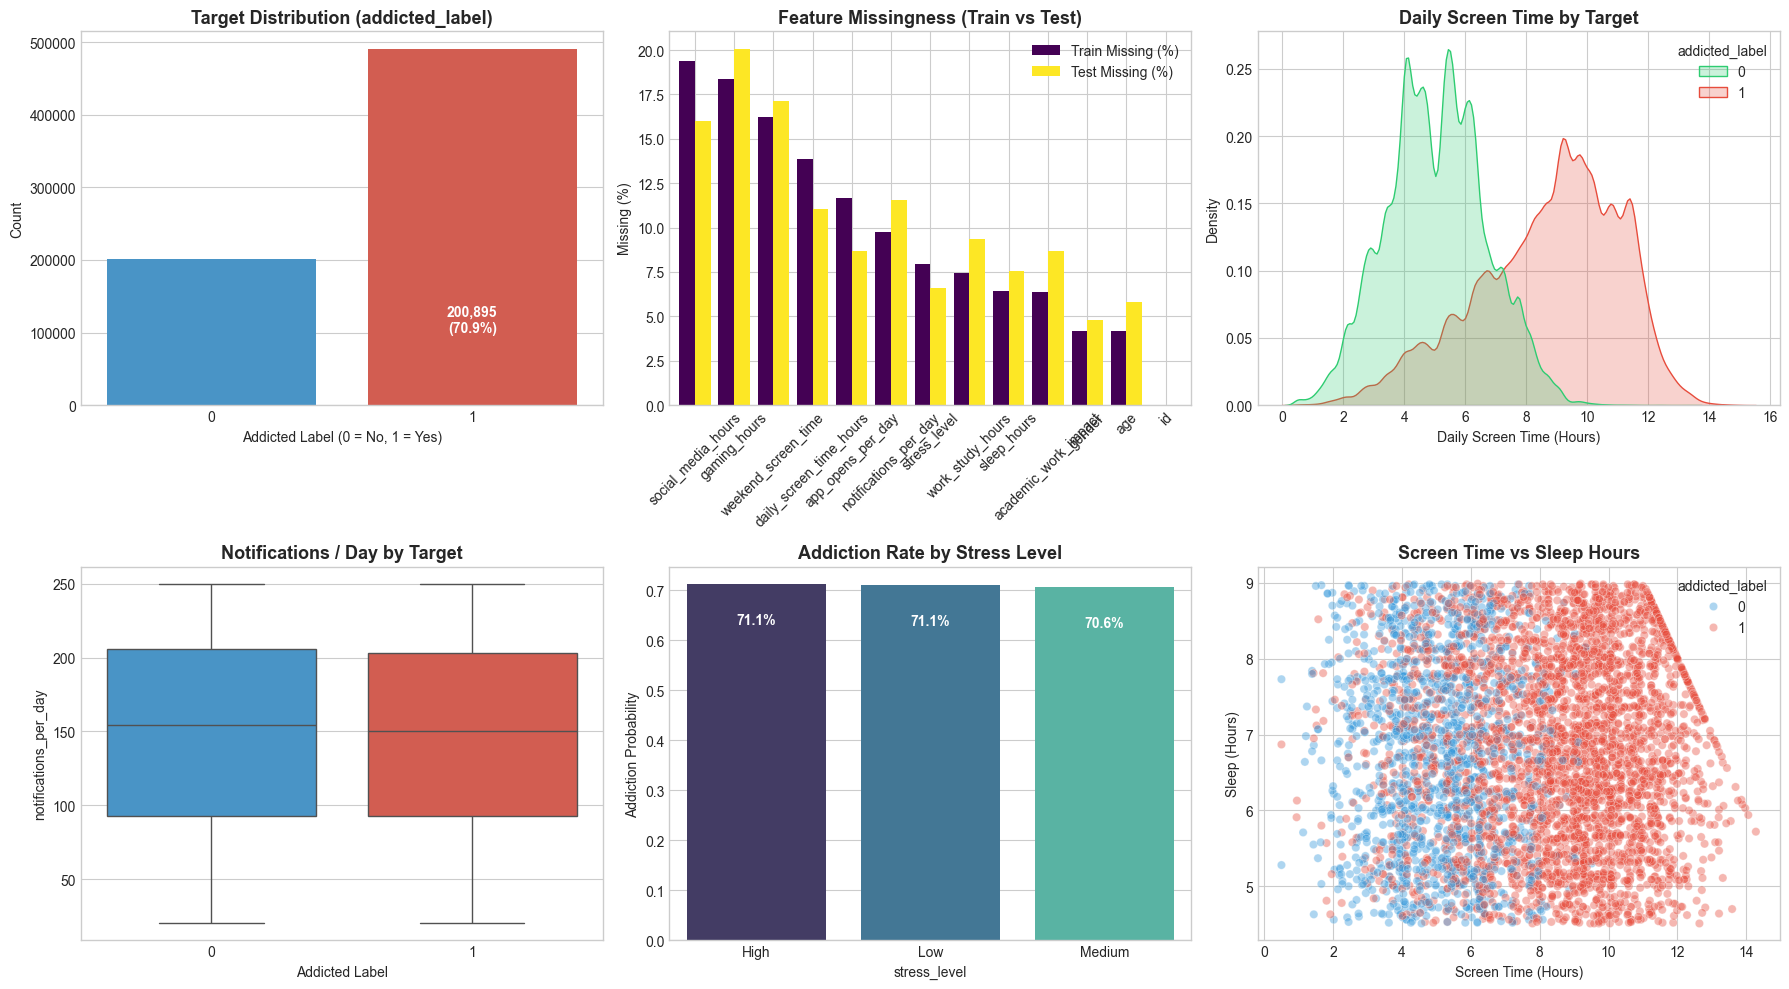

In [3]:
# =============================================================================
# 3. EXPLORATORY DATA ANALYSIS & VISUALIZATION
# =============================================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Target Distribution
sns.barplot(x=target_counts.index, y=target_counts.values, ax=axes[0, 0], palette=["#3498db", "#e74c3c"])
axes[0, 0].set_title("Target Distribution (addicted_label)", fontsize=13, fontweight="bold")
axes[0, 0].set_xlabel("Addicted Label (0 = No, 1 = Yes)")
axes[0, 0].set_ylabel("Count")
for i, v in enumerate(target_counts.values):
    axes[0, 0].text(i, v * 0.5, f"{v:,}\n({target_pct[i]:.1f}%)", ha="center", color="white", fontweight="bold")

# 2. Missing Value Percentages (Train vs Test)
missing_train = (df_train.drop(columns=["addicted_label"]).isnull().sum() / len(df_train)) * 100
missing_test = (df_test.isnull().sum() / len(df_test)) * 100
missing_df = pd.DataFrame({"Train Missing (%)": missing_train, "Test Missing (%)": missing_test}).sort_values(by="Train Missing (%)", ascending=False)
missing_df.plot(kind="bar", ax=axes[0, 1], colormap="viridis", width=0.8)
axes[0, 1].set_title("Feature Missingness (Train vs Test)", fontsize=13, fontweight="bold")
axes[0, 1].set_ylabel("Missing (%)")
axes[0, 1].tick_params(axis="x", rotation=45)

# 3. Daily Screen Time vs Target
sns.kdeplot(data=df_train, x="daily_screen_time_hours", hue="addicted_label", common_norm=False, fill=True, ax=axes[0, 2], palette=["#2ecc71", "#e74c3c"])
axes[0, 2].set_title("Daily Screen Time by Target", fontsize=13, fontweight="bold")
axes[0, 2].set_xlabel("Daily Screen Time (Hours)")

# 4. Notifications vs Target
sns.boxplot(data=df_train, x="addicted_label", y="notifications_per_day", ax=axes[1, 0], palette=["#3498db", "#e74c3c"])
axes[1, 0].set_title("Notifications / Day by Target", fontsize=13, fontweight="bold")
axes[1, 0].set_xlabel("Addicted Label")

# 5. Stress Level Addiction Rate
stress_rate = df_train.groupby("stress_level")["addicted_label"].mean().reset_index()
sns.barplot(data=stress_rate, x="stress_level", y="addicted_label", ax=axes[1, 1], palette="mako")
axes[1, 1].set_title("Addiction Rate by Stress Level", fontsize=13, fontweight="bold")
axes[1, 1].set_ylabel("Addiction Probability")
for i, r in stress_rate.iterrows():
    axes[1, 1].text(i, r["addicted_label"] - 0.08, f"{r['addicted_label']*100:.1f}%", ha="center", color="white", fontweight="bold")

# 6. Sleep Hours vs Screen Time Hexbin/Scatter
sample_plot = df_train.dropna(subset=["daily_screen_time_hours", "sleep_hours"]).sample(n=5000, random_state=42)
sns.scatterplot(data=sample_plot, x="daily_screen_time_hours", y="sleep_hours", hue="addicted_label", alpha=0.4, ax=axes[1, 2], palette=["#3498db", "#e74c3c"])
axes[1, 2].set_title("Screen Time vs Sleep Hours", fontsize=13, fontweight="bold")
axes[1, 2].set_xlabel("Screen Time (Hours)")
axes[1, 2].set_ylabel("Sleep (Hours)")

plt.tight_layout()
plt.show()

In [4]:
# =============================================================================
# 4. ADVANCED FEATURE ENGINEERING ENGINE
# =============================================================================
def engineer_features(df_input, is_train=True):
    """
    Engineers comprehensive predictive features for smartphone addiction detection:
    1. Missingness signals & total null counts
    2. Screen time breakdown & activity ratios (social, gaming, study, entertainment)
    3. Interaction intensity metrics (notifications/open, opens/hour, minutes/open)
    4. Weekend vs weekday screen time divergence & balance metrics
    5. Sleep deficit and health pressure indicators
    6. Categorical ordinal and interaction features
    """
    df = df_input.copy()
    
    # 1. Missingness Indicators & Missing Count
    raw_cols = [c for c in df.columns if c not in ["id", "addicted_label"]]
    df["num_missing_features"] = df[raw_cols].isnull().sum(axis=1).astype(np.int8)
    for col in ["daily_screen_time_hours", "social_media_hours", "gaming_hours", 
                "work_study_hours", "sleep_hours", "notifications_per_day", 
                "app_opens_per_day", "weekend_screen_time"]:
        df[f"isna_{col}"] = df[col].isnull().astype(np.int8)
    
    # 2. Activity Composition & Proportions
    eps = 1e-4
    # Entertainment hours
    df["entertainment_hours"] = df["social_media_hours"].fillna(0) + df["gaming_hours"].fillna(0)
    
    # Proportion of daily screen time allocated to social media / gaming / entertainment
    df["social_media_ratio"] = df["social_media_hours"] / (df["daily_screen_time_hours"] + eps)
    df["gaming_ratio"] = df["gaming_hours"] / (df["daily_screen_time_hours"] + eps)
    df["entertainment_ratio"] = df["entertainment_hours"] / (df["daily_screen_time_hours"] + eps)
    df["work_study_ratio"] = df["work_study_hours"] / (df["daily_screen_time_hours"] + eps)
    
    # Work to entertainment ratio (Productivity balance)
    df["work_to_entertainment_ratio"] = df["work_study_hours"] / (df["entertainment_hours"] + eps)
    
    # Unaccounted Screen Time (screen time not explained by social, gaming, or work)
    df["unaccounted_screen_time"] = df["daily_screen_time_hours"] - (
        df["social_media_hours"].fillna(0) + df["gaming_hours"].fillna(0) + df["work_study_hours"].fillna(0)
    )
    
    # 3. Weekend vs Weekday Usage Dynamics
    df["weekend_to_daily_ratio"] = df["weekend_screen_time"] / (df["daily_screen_time_hours"] + eps)
    df["weekend_screen_diff"] = df["weekend_screen_time"] - df["daily_screen_time_hours"]
    
    # Estimated weekly screen time
    df["weekly_screen_time_est"] = 5.0 * df["daily_screen_time_hours"] + 2.0 * df["weekend_screen_time"]
    
    # 4. App Engagement & Notification Dynamics
    df["notifications_per_screen_hour"] = df["notifications_per_day"] / (df["daily_screen_time_hours"] + eps)
    df["app_opens_per_screen_hour"] = df["app_opens_per_day"] / (df["daily_screen_time_hours"] + eps)
    df["notifications_per_open"] = df["notifications_per_day"] / (df["app_opens_per_day"] + eps)
    df["screen_minutes_per_open"] = (df["daily_screen_time_hours"] * 60.0) / (df["app_opens_per_day"] + eps)
    
    # 5. Sleep & Daily Schedule Balance
    df["sleep_to_screen_ratio"] = df["sleep_hours"] / (df["daily_screen_time_hours"] + eps)
    df["total_accounted_day_hours"] = df["daily_screen_time_hours"].fillna(0) + df["work_study_hours"].fillna(0) + df["sleep_hours"].fillna(0)
    df["free_time_proxy"] = 24.0 - df["total_accounted_day_hours"]
    
    # Extreme behavioral flags
    df["is_sleep_deprived"] = (df["sleep_hours"] < 6.0).astype(np.float32)
    df["is_heavy_screen_user"] = (df["daily_screen_time_hours"] > 8.0).astype(np.float32)
    df["high_screen_low_sleep"] = (df["is_heavy_screen_user"] * df["is_sleep_deprived"]).astype(np.float32)
    
    # 6. Age & Demographic Binning
    df["age_group"] = pd.cut(
        df["age"], 
        bins=[0, 20, 25, 30, 100], 
        labels=[0, 1, 2, 3]
    ).astype(float)
    
    # 7. Categorical Ordinal & Tuple Encodings
    stress_map = {"Low": 0, "Medium": 1, "High": 2}
    impact_map = {"No": 0, "Yes": 1}
    gender_map = {"Male": 0, "Female": 1, "Other": 2}
    
    df["stress_level_num"] = df["stress_level"].map(stress_map)
    df["academic_impact_num"] = df["academic_work_impact"].map(impact_map)
    df["gender_num"] = df["gender"].map(gender_map)
    
    # Combined interaction categories
    df["gender_stress"] = df["gender"].fillna("Missing").astype(str) + "_" + df["stress_level"].fillna("Missing").astype(str)
    df["stress_impact"] = df["stress_level"].fillna("Missing").astype(str) + "_" + df["academic_work_impact"].fillna("Missing").astype(str)
    
    # Stress-weighted Screen Time
    df["stress_weighted_screen_time"] = df["daily_screen_time_hours"] * (df["stress_level_num"].fillna(1) + 1.0)
    
    return df

print("Engineering features on train & test sets...")
t0 = time.time()
df_train_fe = engineer_features(df_train, is_train=True)
df_test_fe = engineer_features(df_test, is_train=False)

# Categorical label encoding for interaction string columns
cat_str_cols = ["gender", "stress_level", "academic_work_impact", "gender_stress", "stress_impact"]
for c in cat_str_cols:
    le = LabelEncoder()
    combined = pd.concat([df_train_fe[c].astype(str), df_test_fe[c].astype(str)], axis=0)
    le.fit(combined)
    df_train_fe[c + "_cat"] = le.transform(df_train_fe[c].astype(str))
    df_test_fe[c + "_cat"] = le.transform(df_test_fe[c].astype(str))

# Group aggregation features: Mean & Std screen time by demographic clusters
group_keys = ["gender_num", "stress_level_num"]
agg_stats = df_train_fe.groupby(group_keys)["daily_screen_time_hours"].agg(["mean", "std"]).reset_index()
agg_stats.columns = group_keys + ["group_screen_time_mean", "group_screen_time_std"]

df_train_fe = df_train_fe.merge(agg_stats, on=group_keys, how="left")
df_test_fe = df_test_fe.merge(agg_stats, on=group_keys, how="left")

df_train_fe["screen_time_diff_group_mean"] = df_train_fe["daily_screen_time_hours"] - df_train_fe["group_screen_time_mean"]
df_test_fe["screen_time_diff_group_mean"] = df_test_fe["daily_screen_time_hours"] - df_test_fe["group_screen_time_mean"]

# Drop raw string columns
drop_cols = ["id", "addicted_label"] + cat_str_cols
features = [c for c in df_train_fe.columns if c not in drop_cols]

X = df_train_fe[features]
y = df_train_fe["addicted_label"].values
X_test = df_test_fe[features]

print(f"Feature engineering complete in {time.time()-t0:.2f}s.")
print(f"Total feature count: {len(features)}")
print(f"Feature list: {features}")

Engineering features on train & test sets...
Feature engineering complete in 2.64s.
Total feature count: 51
Feature list: ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'num_missing_features', 'isna_daily_screen_time_hours', 'isna_social_media_hours', 'isna_gaming_hours', 'isna_work_study_hours', 'isna_sleep_hours', 'isna_notifications_per_day', 'isna_app_opens_per_day', 'isna_weekend_screen_time', 'entertainment_hours', 'social_media_ratio', 'gaming_ratio', 'entertainment_ratio', 'work_study_ratio', 'work_to_entertainment_ratio', 'unaccounted_screen_time', 'weekend_to_daily_ratio', 'weekend_screen_diff', 'weekly_screen_time_est', 'notifications_per_screen_hour', 'app_opens_per_screen_hour', 'notifications_per_open', 'screen_minutes_per_open', 'sleep_to_screen_ratio', 'total_accounted_day_hours', 'free_time_proxy', 'is_sleep_deprived', 'is_heavy_screen_user'

  XGBOOST FEATURE IMPORTANCE ANALYSIS

Running 5-fold XGBoost CV for feature importance...
  Fold 1 — ROC-AUC: 0.95726
  Fold 2 — ROC-AUC: 0.95807
  Fold 3 — ROC-AUC: 0.95867
  Fold 4 — ROC-AUC: 0.95932
  Fold 5 — ROC-AUC: 0.95812

--> Mean OOF ROC-AUC: 0.95829 (±0.00069)

--- Top 20 Features by Composite Importance Score ---
                    feature        gain  weight        cover  composite_score
       is_heavy_screen_user 5218.206934    26.4 18221.067383         0.671463
          app_opens_per_day   89.837541  1834.6 12252.363672         0.563215
      notifications_per_day   89.547061  1834.4 11200.926563         0.543925
    daily_screen_time_hours 1600.863940   812.0 10886.777344         0.448957
        weekend_screen_time  428.215625  1324.4  9164.108398         0.435634
         social_media_hours  478.740936  1029.2  8372.501660         0.370745
                        age   34.412334   330.2 12238.118945         0.286075
           work_study_ratio   97.643169   512.4 

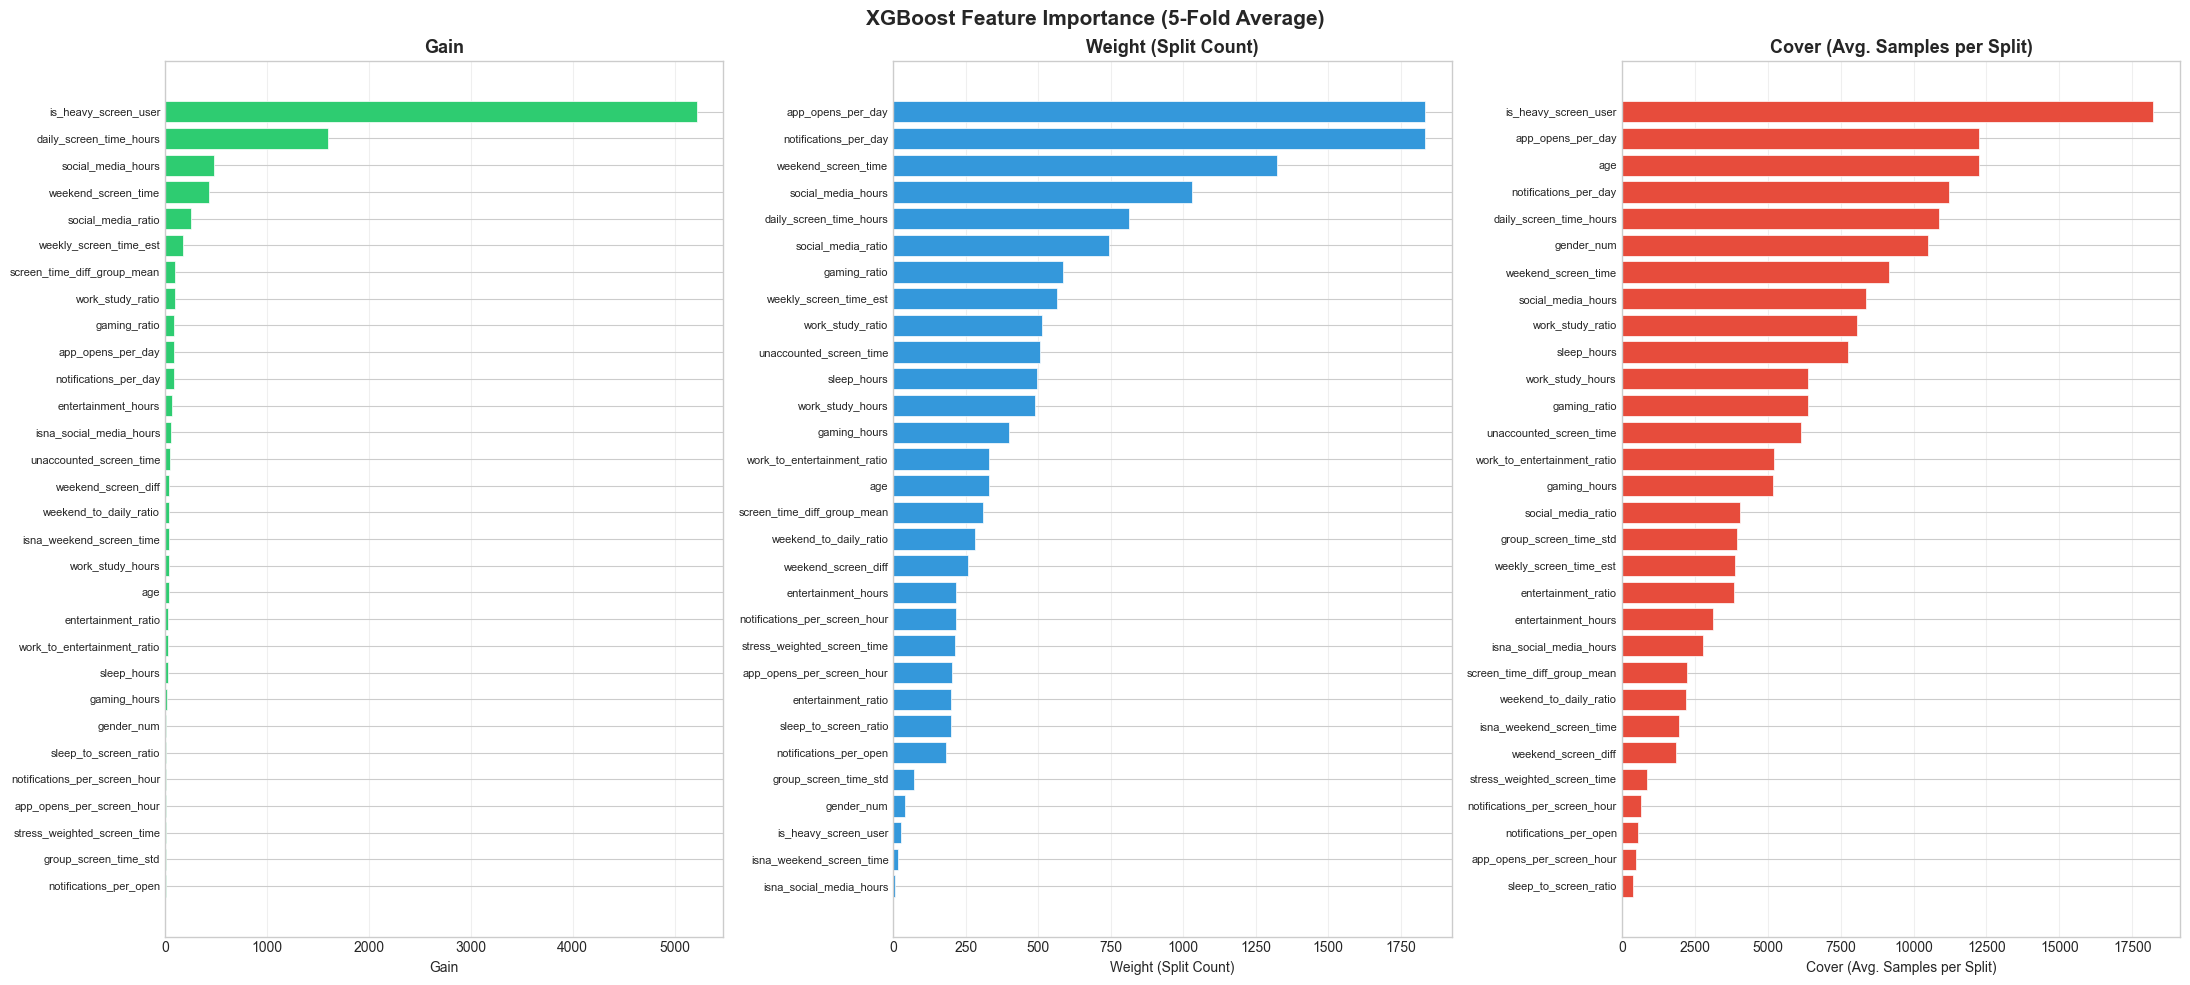

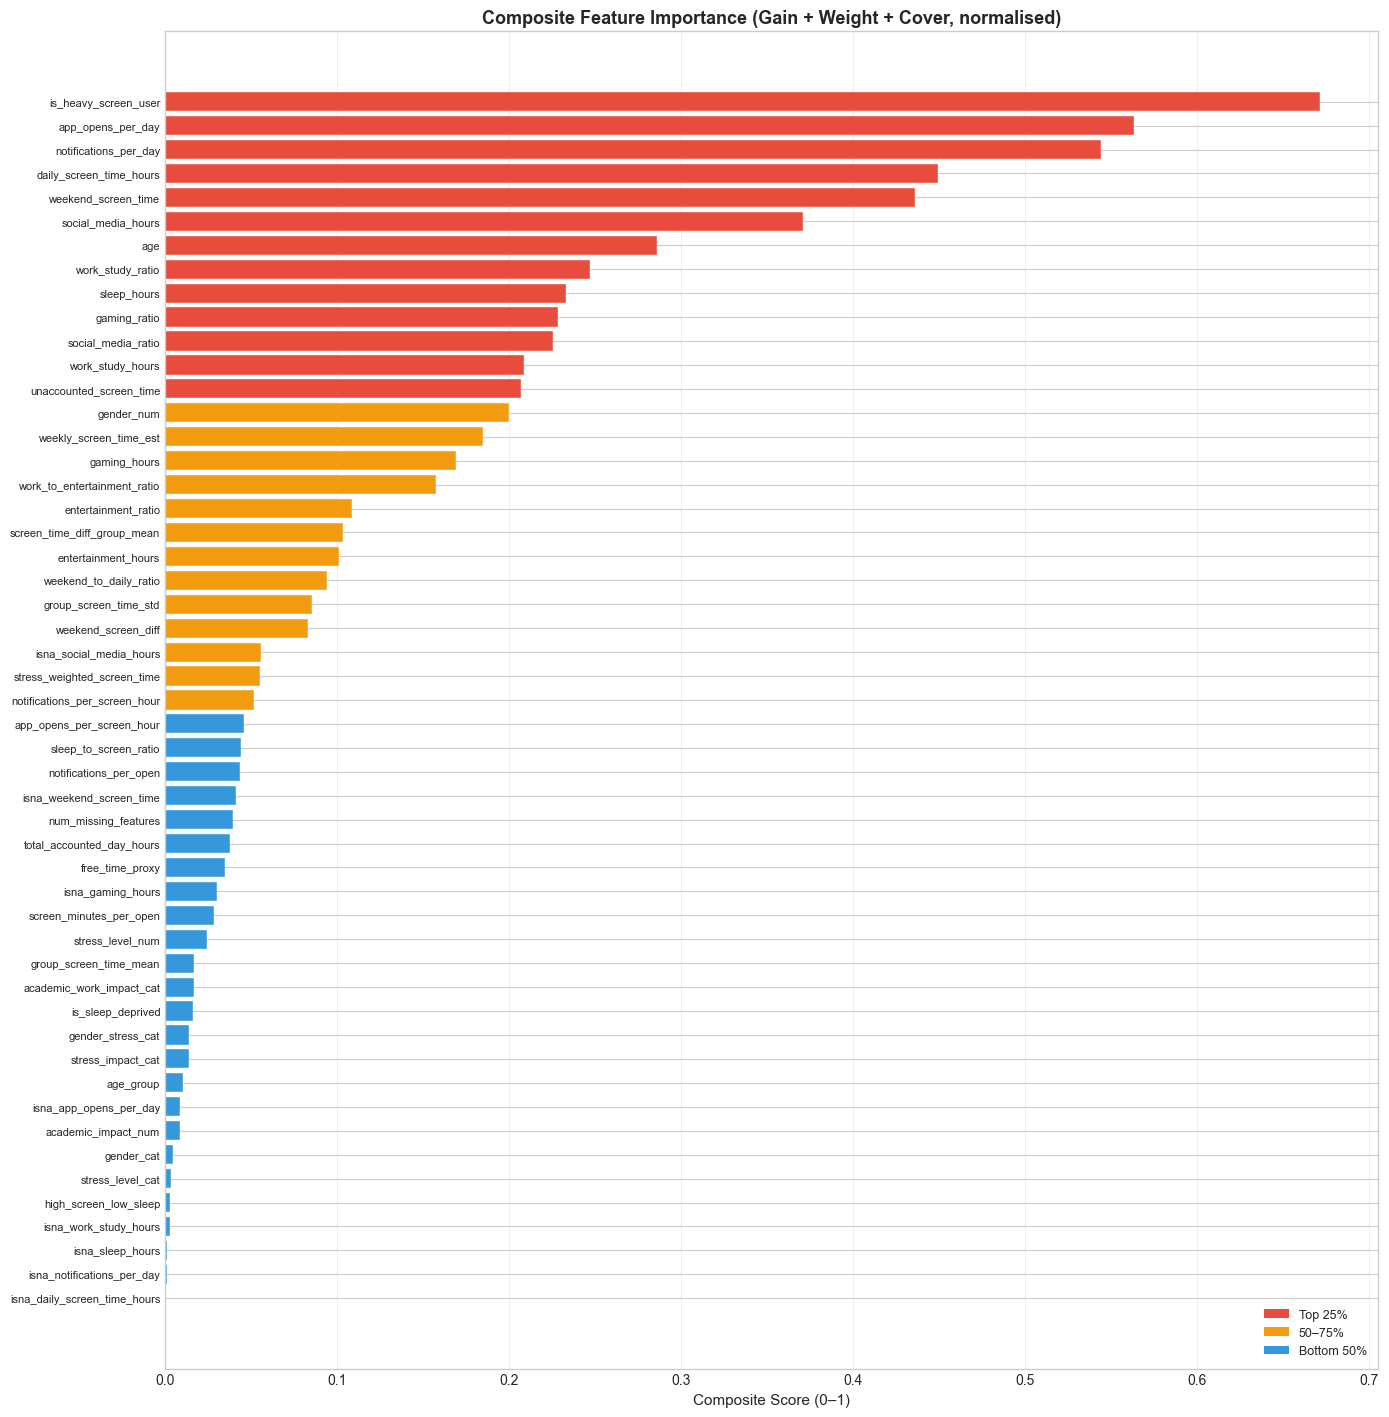

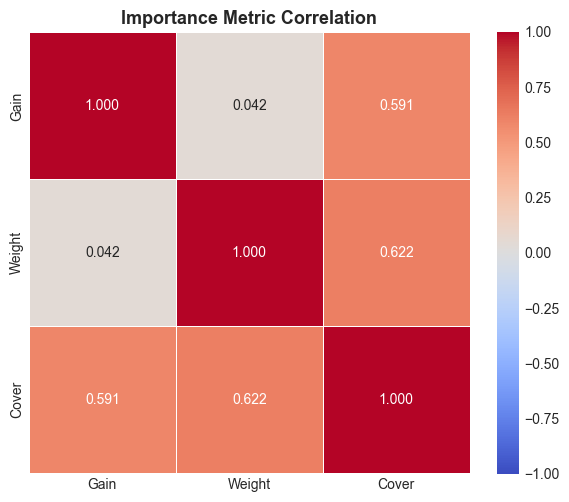


[!] Features with ZERO importance across all folds (1):
    - isna_daily_screen_time_hours

✓ Feature importance analysis complete.


In [5]:
# =============================================================================
# 5. FEATURE IMPORTANCE ANALYSIS USING XGBOOST
# =============================================================================
# This section uses XGBoost to measure the effect/importance of each feature.
# We train XGBoost with cross-validation and aggregate multiple importance measures:
#   - Gain:    How much each feature contributes to improving accuracy (most informative)
#   - Weight:  Number of times a feature is used in a split
#   - Cover:   Mean coverage (number of samples affected by a feature across splits)

import xgboost as xgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

print("=" * 70)
print("  XGBOOST FEATURE IMPORTANCE ANALYSIS")
print("=" * 70)

# -------------------------------------------------------------------------
# XGBoost parameters (tuned for fast, informative importance estimation)
# -------------------------------------------------------------------------
XGB_PARAMS = {
    "objective":        "binary:logistic",
    "eval_metric":      "auc",
    "tree_method":      "hist",
    "device":           "cuda",          # CPU-friendly; change to 'gpu_hist' for GPU
    "learning_rate":    0.05,
    "max_depth":        5,
    "subsample":        0.8,
    "colsample_bytree": 0.8,
    "n_estimators":     500,
    "early_stopping_rounds": 30,
    "random_state":     SEED,
    "n_jobs":           -1,
    "verbosity":        0,
}

# -------------------------------------------------------------------------
# Cross-Validation loop — accumulate importances across folds
# -------------------------------------------------------------------------
N_SPLITS_FI = 5
skf_fi = StratifiedKFold(n_splits=N_SPLITS_FI, shuffle=True, random_state=SEED)

importance_gain_all   = np.zeros(len(features))
importance_weight_all = np.zeros(len(features))
importance_cover_all  = np.zeros(len(features))
fold_aucs             = []

print(f"\nRunning {N_SPLITS_FI}-fold XGBoost CV for feature importance...")

for fold, (trn_idx, val_idx) in enumerate(skf_fi.split(X, y)):
    X_trn, y_trn = X.iloc[trn_idx], y[trn_idx]
    X_val, y_val = X.iloc[val_idx], y[val_idx]

    model = xgb.XGBClassifier(**XGB_PARAMS)
    model.fit(
        X_trn, y_trn,
        eval_set=[(X_val, y_val)],
        verbose=False,
    )

    val_preds = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, val_preds)
    fold_aucs.append(auc)
    print(f"  Fold {fold + 1} — ROC-AUC: {auc:.5f}")

    # Accumulate importances
    gain_scores   = model.get_booster().get_score(importance_type="gain")
    weight_scores = model.get_booster().get_score(importance_type="weight")
    cover_scores  = model.get_booster().get_score(importance_type="cover")

    for j, feat in enumerate(features):
        importance_gain_all[j]   += gain_scores.get(feat, 0.0)
        importance_weight_all[j] += weight_scores.get(feat, 0.0)
        importance_cover_all[j]  += cover_scores.get(feat, 0.0)

print(f"\n--> Mean OOF ROC-AUC: {np.mean(fold_aucs):.5f} (±{np.std(fold_aucs):.5f})")

# Average across folds
importance_gain_avg   = importance_gain_all   / N_SPLITS_FI
importance_weight_avg = importance_weight_all / N_SPLITS_FI
importance_cover_avg  = importance_cover_all  / N_SPLITS_FI

# -------------------------------------------------------------------------
# Build summary DataFrame
# -------------------------------------------------------------------------
importance_df = pd.DataFrame({
    "feature":        features,
    "gain":           importance_gain_avg,
    "weight":         importance_weight_avg,
    "cover":          importance_cover_avg,
})

# Normalize each metric 0-1 so they're comparable
for metric in ["gain", "weight", "cover"]:
    max_val = importance_df[metric].max()
    if max_val > 0:
        importance_df[f"{metric}_norm"] = importance_df[metric] / max_val
    else:
        importance_df[f"{metric}_norm"] = 0.0

# Composite score: equally-weighted average of normalised metrics
importance_df["composite_score"] = (
    importance_df["gain_norm"] +
    importance_df["weight_norm"] +
    importance_df["cover_norm"]
) / 3.0

importance_df.sort_values("composite_score", ascending=False, inplace=True)
importance_df.reset_index(drop=True, inplace=True)

print("\n--- Top 20 Features by Composite Importance Score ---")
print(importance_df[["feature", "gain", "weight", "cover", "composite_score"]].head(20).to_string(index=False))

# -------------------------------------------------------------------------
# Visualization 1: Top-30 Feature Importances (Gain)
# -------------------------------------------------------------------------
TOP_N = 30
top_df = importance_df.head(TOP_N)

fig, axes = plt.subplots(1, 3, figsize=(22, 10))
fig.suptitle("XGBoost Feature Importance (5-Fold Average)", fontsize=15, fontweight="bold")

metrics_info = [
    ("gain",   "Gain",   "#2ecc71"),
    ("weight", "Weight (Split Count)", "#3498db"),
    ("cover",  "Cover (Avg. Samples per Split)", "#e74c3c"),
]

for ax, (metric, label, color) in zip(axes, metrics_info):
    sorted_top = top_df.sort_values(metric, ascending=True)
    ax.barh(sorted_top["feature"], sorted_top[metric], color=color, edgecolor="white", linewidth=0.5)
    ax.set_title(label, fontsize=13, fontweight="bold")
    ax.set_xlabel(label, fontsize=10)
    ax.tick_params(axis="y", labelsize=8)
    ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# Visualization 2: Composite Score Bar Chart (all features)
# -------------------------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(14, max(6, len(features) * 0.28)))
sorted_all = importance_df.sort_values("composite_score", ascending=True)
colors = ["#e74c3c" if s >= sorted_all["composite_score"].quantile(0.75) else
          "#f39c12" if s >= sorted_all["composite_score"].quantile(0.50) else
          "#3498db" for s in sorted_all["composite_score"]]

ax2.barh(sorted_all["feature"], sorted_all["composite_score"], color=colors, edgecolor="white", linewidth=0.3)
ax2.set_title("Composite Feature Importance (Gain + Weight + Cover, normalised)", fontsize=13, fontweight="bold")
ax2.set_xlabel("Composite Score (0–1)", fontsize=11)
ax2.tick_params(axis="y", labelsize=8)
ax2.grid(axis="x", alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#e74c3c", label="Top 25%"),
    Patch(facecolor="#f39c12", label="50–75%"),
    Patch(facecolor="#3498db", label="Bottom 50%"),
]
ax2.legend(handles=legend_elements, loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# Visualization 3: Heatmap — Correlation between importance metrics
# -------------------------------------------------------------------------
corr_df = importance_df[["gain_norm", "weight_norm", "cover_norm"]].rename(
    columns={"gain_norm": "Gain", "weight_norm": "Weight", "cover_norm": "Cover"}
)
fig3, ax3 = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_df.corr(), annot=True, fmt=".3f", cmap="coolwarm", vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax3)
ax3.set_title("Importance Metric Correlation", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# Print zero-importance features (potentially removable)
# -------------------------------------------------------------------------
zero_importance = importance_df[importance_df["composite_score"] == 0]["feature"].tolist()
if zero_importance:
    print(f"\n[!] Features with ZERO importance across all folds ({len(zero_importance)}):")
    for f in zero_importance:
        print(f"    - {f}")
else:
    print("\n✓ All features have non-zero importance.")

print("\n✓ Feature importance analysis complete.")


  INCREMENTAL FEATURE ADDITION — ROC-AUC IMPACT ANALYSIS

Baseline feature set  : 12 original columns
Features to add       : 39 engineered columns
Addition order        : by composite importance score (Cell 5)

Computing baseline ROC-AUC (original features)...
  Baseline ROC-AUC : 0.95082

Step  Feature Added                                    ROC-AUC      Delta  Impact
--------------------------------------------------------------------------------
   0  --- BASELINE (raw only) ---                      0.95082             baseline
   1  is_heavy_screen_user                             0.95069   -0.00013  ❌ HURTS
   2  work_study_ratio                                 0.95142   +0.00074  ✅ improve
   3  gaming_ratio                                     0.95187   +0.00044  ✅ improve
   4  social_media_ratio                               0.95256   +0.00070  ✅ improve
   5  unaccounted_screen_time                          0.95332   +0.00076  ✅ improve
   6  gender_num                      

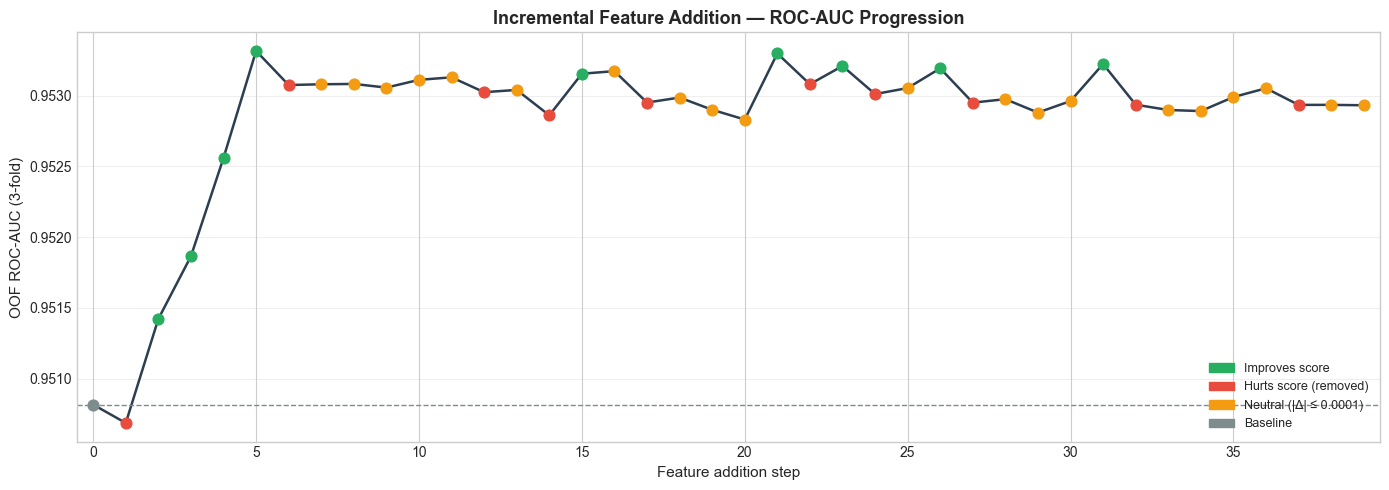

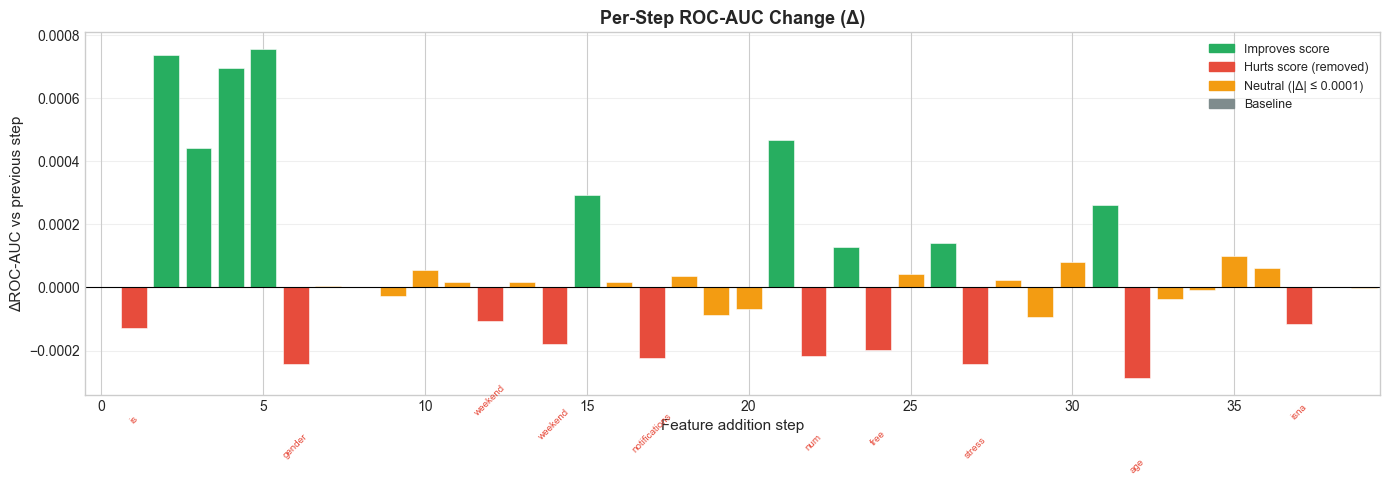


✓ Incremental feature impact analysis complete.


In [6]:
# =============================================================================
# 6. INCREMENTAL FEATURE ADDITION — ROC-AUC IMPACT ANALYSIS
# =============================================================================
# Strategy:
#   1. Start with the original raw dataset columns only (baseline).
#   2. Add each engineered feature one at a time, in order of composite
#      importance (most important first, from Cell 5).
#   3. Record the 3-fold OOF ROC-AUC at every step.
#   4. Features that DECREASE the score are flagged as harmful.
#
# This answers: "Does adding this feature actually help or hurt?"
# =============================================================================

import xgboost as xgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

# -------------------------------------------------------------------------
# Identify original (raw) features vs engineered features
# -------------------------------------------------------------------------
# These are the columns that came directly from the CSV — after label-encoding
# the categorical ones but before any ratio/interaction engineering.
ORIGINAL_FEATURES = [
    "age",
    "daily_screen_time_hours",
    "social_media_hours",
    "gaming_hours",
    "work_study_hours",
    "sleep_hours",
    "notifications_per_day",
    "app_opens_per_day",
    "weekend_screen_time",
    # label-encoded versions of the raw categorical columns
    "gender_cat",
    "stress_level_cat",
    "academic_work_impact_cat",
]

# Keep only those that actually exist in X
original_feats = [f for f in ORIGINAL_FEATURES if f in features]

# Engineered features = everything else, ordered by composite importance (best first)
engineered_feats = [
    f for f in importance_df["feature"].tolist()   # already sorted best→worst
    if f not in original_feats
]

print("=" * 70)
print("  INCREMENTAL FEATURE ADDITION — ROC-AUC IMPACT ANALYSIS")
print("=" * 70)
print(f"\nBaseline feature set  : {len(original_feats)} original columns")
print(f"Features to add       : {len(engineered_feats)} engineered columns")
print(f"Addition order        : by composite importance score (Cell 5)\n")

# -------------------------------------------------------------------------
# Fast 3-fold CV function using XGBoost
# -------------------------------------------------------------------------
XGB_FAST_PARAMS = {
    "objective":        "binary:logistic",
    "eval_metric":      "auc",
    "tree_method":      "hist",
    "learning_rate":    0.05,
    "max_depth":        5,
    "subsample":        0.8,
    "colsample_bytree": 0.8,
    "n_estimators":     300,
    "random_state":     SEED,
    "n_jobs":           -1,
    "verbosity":        0,
}

def cv_roc_auc(feature_subset, n_splits=3):
    """Return mean OOF ROC-AUC for a given feature subset."""
    X_sub = X[feature_subset]
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    oof = np.zeros(len(y))
    for trn_idx, val_idx in skf.split(X_sub, y):
        mdl = xgb.XGBClassifier(**XGB_FAST_PARAMS)
        mdl.fit(X_sub.iloc[trn_idx], y[trn_idx], verbose=False)
        oof[val_idx] = mdl.predict_proba(X_sub.iloc[val_idx])[:, 1]
    return roc_auc_score(y, oof)

# -------------------------------------------------------------------------
# Step 0: Baseline ROC-AUC (original features only)
# -------------------------------------------------------------------------
print("Computing baseline ROC-AUC (original features)...")
baseline_auc = cv_roc_auc(original_feats)
print(f"  Baseline ROC-AUC : {baseline_auc:.5f}\n")

# -------------------------------------------------------------------------
# Step 1..N: Add each engineered feature and measure ROC-AUC
# -------------------------------------------------------------------------
current_feats = original_feats.copy()
results = [
    {
        "step":        0,
        "feature":     "--- BASELINE (raw only) ---",
        "n_features":  len(original_feats),
        "roc_auc":     baseline_auc,
        "delta":       0.0,
        "impact":      "baseline",
    }
]

print(f"{'Step':>4}  {'Feature Added':<45}  {'ROC-AUC':>9}  {'Delta':>9}  Impact")
print("-" * 80)
print(f"{'0':>4}  {'--- BASELINE (raw only) ---':<45}  {baseline_auc:>9.5f}  {'':>9}  baseline")

for step, feat in enumerate(engineered_feats, start=1):
    current_feats.append(feat)
    auc = cv_roc_auc(current_feats)
    delta = auc - results[-1]["roc_auc"]   # vs PREVIOUS step

    if delta > 0.0001:
        impact = "✅ improve"
    elif delta < -0.0001:
        impact = "❌ HURTS"
        current_feats.pop()                # remove harmful feature
    else:
        impact = "➡ neutral"

    results.append({
        "step":       step,
        "feature":    feat,
        "n_features": len(current_feats),
        "roc_auc":    auc,
        "delta":      delta,
        "impact":     impact,
    })
    print(f"{step:>4}  {feat:<45}  {auc:>9.5f}  {delta:>+9.5f}  {impact}")

print("-" * 80)

# -------------------------------------------------------------------------
# Summary DataFrame
# -------------------------------------------------------------------------
results_df = pd.DataFrame(results)
final_auc   = results_df["roc_auc"].iloc[-1]
total_delta = final_auc - baseline_auc

print(f"\n{'='*70}")
print(f"  SUMMARY")
print(f"{'='*70}")
print(f"  Baseline ROC-AUC        : {baseline_auc:.5f}")
print(f"  Final ROC-AUC           : {final_auc:.5f}")
print(f"  Total improvement       : {total_delta:+.5f}")
print()

# Features that hurt
hurts = results_df[results_df["impact"].str.startswith("❌")]
if len(hurts):
    print(f"  Features that HURT performance ({len(hurts)}) — removed from set:")
    for _, row in hurts.iterrows():
        print(f"    - {row['feature']:45s}  delta={row['delta']:+.5f}")
else:
    print("  No features hurt performance.")

neutrals = results_df[results_df["impact"] == "➡ neutral"]
if len(neutrals):
    print(f"\n  Features with NEUTRAL impact ({len(neutrals)}) — kept but marginal:")
    for _, row in neutrals.iterrows():
        print(f"    - {row['feature']:45s}  delta={row['delta']:+.5f}")

# -------------------------------------------------------------------------
# Plot 1: Cumulative ROC-AUC progression
# -------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 5))

steps  = results_df["step"].values
aucs   = results_df["roc_auc"].values
deltas = results_df["delta"].values
impacts = results_df["impact"].values

# Line
ax.plot(steps, aucs, color="#2c3e50", linewidth=1.8, zorder=2)

# Colour-coded scatter dots
color_map = {
    "baseline":  "#7f8c8d",
    "✅ improve": "#27ae60",
    "❌ HURTS":   "#e74c3c",
    "➡ neutral":  "#f39c12",
}
for s, a, imp in zip(steps, aucs, impacts):
    ax.scatter(s, a, color=color_map.get(imp, "grey"), s=60, zorder=3)

# Baseline reference line
ax.axhline(baseline_auc, color="#7f8c8d", linestyle="--", linewidth=1, label=f"Baseline ({baseline_auc:.4f})")

ax.set_xlabel("Feature addition step", fontsize=11)
ax.set_ylabel("OOF ROC-AUC (3-fold)", fontsize=11)
ax.set_title("Incremental Feature Addition — ROC-AUC Progression", fontsize=13, fontweight="bold")
ax.grid(axis="y", alpha=0.3)
ax.set_xlim(-0.5, len(results_df) - 0.5)

legend_patches = [
    mpatches.Patch(color="#27ae60", label="Improves score"),
    mpatches.Patch(color="#e74c3c", label="Hurts score (removed)"),
    mpatches.Patch(color="#f39c12", label="Neutral (|Δ| ≤ 0.0001)"),
    mpatches.Patch(color="#7f8c8d", label="Baseline"),
]
ax.legend(handles=legend_patches, loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# Plot 2: Per-step Delta bar chart
# -------------------------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(14, 5))
bar_colors = [color_map.get(i, "grey") for i in impacts]
ax2.bar(steps, deltas, color=bar_colors, edgecolor="white", linewidth=0.4)
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_xlabel("Feature addition step", fontsize=11)
ax2.set_ylabel("ΔROC-AUC vs previous step", fontsize=11)
ax2.set_title("Per-Step ROC-AUC Change (Δ)", fontsize=13, fontweight="bold")
ax2.grid(axis="y", alpha=0.3)
ax2.set_xlim(-0.5, len(results_df) - 0.5)

# Annotate harmful features
for _, row in hurts.iterrows():
    ax2.annotate(
        row["feature"].split("_")[0],
        xy=(row["step"], row["delta"]),
        xytext=(row["step"], row["delta"] - 0.0003),
        fontsize=7, ha="center", color="#e74c3c", rotation=45,
    )

ax2.legend(handles=legend_patches, loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

print("\n✓ Incremental feature impact analysis complete.")


In [9]:
results_df.head()

hurting_features = hurts["feature"].tolist()
print(hurting_features)

#['is_heavy_screen_user', 'gender_num', 'weekend_to_daily_ratio', 'weekend_screen_diff', 'notifications_per_screen_hour', 'num_missing_features', 'free_time_proxy', 'stress_level_num', 'age_group', 'isna_sleep_hours']

['is_heavy_screen_user', 'gender_num', 'weekend_to_daily_ratio', 'weekend_screen_diff', 'notifications_per_screen_hour', 'num_missing_features', 'free_time_proxy', 'stress_level_num', 'age_group', 'isna_sleep_hours']


In [11]:
df_train_fe.head()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,...,stress_impact,stress_weighted_screen_time,gender_cat,stress_level_cat,academic_work_impact_cat,gender_stress_cat,stress_impact_cat,group_screen_time_mean,group_screen_time_std,screen_time_diff_group_mean
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,...,Medium_No,NaN,1,2,0,6,7,7.623100,2.751729,NaN
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,...,Medium_No,11.94,0,2,0,2,7,7.526993,2.748728,-1.556993
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,...,Low_Yes,5.09,0,1,1,1,5,7.627883,2.709966,-2.537883
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,...,Low_Missing,6.42,2,1,2,13,3,7.597973,2.705124,-1.177973
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,...,Medium_No,22.40,0,2,0,2,7,7.526993,2.748728,3.673007


In [12]:
df_train_fe.drop(columns=hurting_features)

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,...,stress_impact,stress_weighted_screen_time,gender_cat,stress_level_cat,academic_work_impact_cat,gender_stress_cat,stress_impact_cat,group_screen_time_mean,group_screen_time_std,screen_time_diff_group_mean
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,...,Medium_No,NaN,1,2,0,6,7,7.623100,2.751729,NaN
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,...,Medium_No,11.940000,0,2,0,2,7,7.526993,2.748728,-1.556993
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,...,Low_Yes,5.090000,0,1,1,1,5,7.627883,2.709966,-2.537883
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,...,Low_Missing,6.420000,2,1,2,13,3,7.597973,2.705124,-1.177973
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,...,Medium_No,22.400000,0,2,0,2,7,7.526993,2.748728,3.673007
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,...,Missing_No,21.559999,1,3,0,7,10,NaN,NaN,NaN
691365,691365,20.0,3.45,1.86,0.89,0.30,6.59,221.0,42.0,8.47,...,High_No,10.350000,0,0,0,0,1,7.661888,2.711734,-4.211887
691366,691366,NaN,NaN,NaN,NaN,2.06,6.16,NaN,86.0,7.79,...,Medium_No,NaN,2,2,0,14,7,7.549941,2.744971,NaN
691367,691367,22.0,11.78,3.69,0.23,1.35,5.53,171.0,62.0,7.71,...,Missing_Missing,23.559999,2,3,2,15,9,NaN,NaN,NaN


In [19]:
# =============================================================================
# 7. FINAL ROC-AUC ON REDUCED FEATURE SET (hurting features removed)
# =============================================================================
import xgboost as xgb
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

# Raw string columns that XGBoost cannot handle
# (the notebook already label-encoded them into *_cat columns)
cat_str_cols = ["gender", "stress_level", "academic_work_impact",
                "gender_stress", "stress_impact"]

# Drop hurting features + raw string columns
cols_to_drop = hurting_features + cat_str_cols
df_reduced = df_train_fe.drop(columns=cols_to_drop, errors="ignore")

# Build feature matrix & target
target_col = "addicted_label"
reduced_features = [c for c in df_reduced.columns if c != target_col]
X_red = df_reduced[reduced_features]
y_red = df_reduced[target_col].values

print(f"Reduced feature set : {len(reduced_features)} features  "
      f"(removed {len(hurting_features)} hurting + {len(cat_str_cols)} raw string cols)")
print(f"Hurting removed     : {hurting_features}\n")

# XGBoost params (same fast config used in incremental analysis)
XGB_PARAMS = {
    "objective":        "binary:logistic",
    "eval_metric":      "auc",
    "tree_method":      "hist",
    "device":           "cuda",          # CPU-friendly; change to 'gpu_hist' for GPU
    "learning_rate":    0.05,
    "max_depth":        5,
    "subsample":        0.8,
    "colsample_bytree": 0.8,
    "n_estimators":     500,
    "early_stopping_rounds": 30,
    "random_state":     SEED,
    "n_jobs":           -1,
    "verbosity":        0,
}


N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
oof_preds = np.zeros(len(y_red))
fold_aucs = []

print(f"Running {N_SPLITS}-fold CV on reduced feature set...")
print(f"{'Fold':<6} {'ROC-AUC':>9}")
print("-" * 20)

for fold, (trn_idx, val_idx) in enumerate(skf.split(X_red, y_red), 1):
    model = xgb.XGBClassifier(**XGB_PARAMS)
    model.fit(X_red.iloc[trn_idx], y_red[trn_idx],eval_set=[(X_red.iloc[val_idx],y_red[val_idx])], verbose=False)
    oof_preds[val_idx] = model.predict_proba(X_red.iloc[val_idx])[:, 1]
    fold_auc = roc_auc_score(y_red[val_idx], oof_preds[val_idx])
    fold_aucs.append(fold_auc)
    print(f"{fold:<6} {fold_auc:>9.5f}")

mean_auc = np.mean(fold_aucs)
std_auc  = np.std(fold_aucs)
oof_auc  = roc_auc_score(y_red, oof_preds)

print("-" * 20)
print(f"\nMean fold AUC : {mean_auc:.5f} ± {std_auc:.5f}")
print(f"Global OOF AUC: {oof_auc:.5f}")



Reduced feature set : 42 features  (removed 10 hurting + 5 raw string cols)
Hurting removed     : ['is_heavy_screen_user', 'gender_num', 'weekend_to_daily_ratio', 'weekend_screen_diff', 'notifications_per_screen_hour', 'num_missing_features', 'free_time_proxy', 'stress_level_num', 'age_group', 'isna_sleep_hours']

Running 5-fold CV on reduced feature set...
Fold     ROC-AUC
--------------------
1        0.95754
2        0.95857
3        0.95845
4        0.95955
5        0.95831
--------------------

Mean fold AUC : 0.95849 ± 0.00064
Global OOF AUC: 0.95848


In [21]:
# =============================================================================
# 7. FINAL ROC-AUC ON REDUCED FEATURE SET (hurting features removed + scaling)
# =============================================================================
import xgboost as xgb
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Raw string columns that XGBoost cannot handle
# (the notebook already label-encoded them into *_cat columns)
cat_str_cols = ["gender", "stress_level", "academic_work_impact",
                "gender_stress", "stress_impact"]

# Drop hurting features + raw string columns
cols_to_drop = hurting_features + cat_str_cols
df_reduced = df_train_fe.drop(columns=cols_to_drop, errors="ignore")

# Build feature matrix & target
target_col = "addicted_label"
reduced_features = [c for c in df_reduced.columns if c != target_col]
X_red = df_reduced[reduced_features]
y_red = df_reduced[target_col].values

# Identify columns to scale vs leave as-is
# - Binary flags (isna_*, is_*, *_cat) and ordinal encodings should NOT be scaled
# - Continuous float features should be scaled
SKIP_SCALING_PREFIXES = ("isna_", "is_", "high_")
SKIP_SCALING_SUFFIXES = ("_cat", "_num", "_group", "_ratio")  # already relative/encoded

num_cols = [
    c for c in reduced_features
    if X_red[c].dtype in [np.float32, np.float64, float]
    and not any(c.startswith(p) for p in SKIP_SCALING_PREFIXES)
    and not any(c.endswith(s) for s in SKIP_SCALING_SUFFIXES)
]

print(f"Reduced feature set : {len(reduced_features)} features  "
      f"(removed {len(hurting_features)} hurting + {len(cat_str_cols)} raw string cols)")
print(f"Hurting removed     : {hurting_features}")
print(f"Columns to scale    : {num_cols}\n")

# XGBoost params
XGB_PARAMS = {
    "objective":             "binary:logistic",
    "eval_metric":           "auc",
    "tree_method":           "hist",
    "device":                "cuda",
    "learning_rate":         0.05,
    "max_depth":             5,
    "subsample":             0.8,
    "colsample_bytree":      0.8,
    "n_estimators":          500,
    "early_stopping_rounds": 30,
    "random_state":          SEED,
    "n_jobs":                -1,
    "verbosity":             0,
}

N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
oof_preds = np.zeros(len(y_red))
fold_aucs = []

print(f"Running {N_SPLITS}-fold CV on reduced feature set...")
print(f"{'Fold':<6} {'ROC-AUC':>9}")
print("-" * 20)

X_red = X_red.reset_index(drop=True)   # ensure clean integer index

for fold, (trn_idx, val_idx) in enumerate(skf.split(X_red, y_red), 1):
    X_trn, X_val = X_red.iloc[trn_idx].copy(), X_red.iloc[val_idx].copy()

    # Fit scaler on train fold only, then apply to both
    scaler = MinMaxScaler()
    X_trn[num_cols] = scaler.fit_transform(X_trn[num_cols])
    X_val[num_cols] = scaler.transform(X_val[num_cols])

    model = xgb.XGBClassifier(**XGB_PARAMS)
    model.fit(X_trn, y_red[trn_idx],
              eval_set=[(X_val, y_red[val_idx])],
              verbose=False)

    oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
    fold_auc = roc_auc_score(y_red[val_idx], oof_preds[val_idx])
    fold_aucs.append(fold_auc)
    print(f"{fold:<6} {fold_auc:>9.5f}")

mean_auc = np.mean(fold_aucs)
std_auc  = np.std(fold_aucs)
oof_auc  = roc_auc_score(y_red, oof_preds)

print("-" * 20)
print(f"\nMean fold AUC : {mean_auc:.5f} ± {std_auc:.5f}")
print(f"Global OOF AUC: {oof_auc:.5f}")


Reduced feature set : 42 features  (removed 10 hurting + 5 raw string cols)
Hurting removed     : ['is_heavy_screen_user', 'gender_num', 'weekend_to_daily_ratio', 'weekend_screen_diff', 'notifications_per_screen_hour', 'num_missing_features', 'free_time_proxy', 'stress_level_num', 'age_group', 'isna_sleep_hours']
Columns to scale    : ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'entertainment_hours', 'unaccounted_screen_time', 'weekly_screen_time_est', 'app_opens_per_screen_hour', 'notifications_per_open', 'screen_minutes_per_open', 'total_accounted_day_hours', 'stress_weighted_screen_time', 'group_screen_time_mean', 'group_screen_time_std', 'screen_time_diff_group_mean']

Running 5-fold CV on reduced feature set...
Fold     ROC-AUC
--------------------
1        0.95725
2        0.95845
3        0.95838
4        0.95939
5        0.95827
------------------

In [22]:
# =============================================================================
# 7. FINAL ROC-AUC ON REDUCED FEATURE SET (hurting features removed + imputation)
# =============================================================================
import xgboost as xgb
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.impute import SimpleImputer

# Raw string columns that XGBoost cannot handle
# (the notebook already label-encoded them into *_cat columns)
cat_str_cols = ["gender", "stress_level", "academic_work_impact",
                "gender_stress", "stress_impact"]

# Drop hurting features + raw string columns
cols_to_drop = hurting_features + cat_str_cols
df_reduced = df_train_fe.drop(columns=cols_to_drop, errors="ignore")

# Build feature matrix & target
target_col = "addicted_label"
reduced_features = [c for c in df_reduced.columns if c != target_col]
X_red = df_reduced[reduced_features].reset_index(drop=True)
y_red = df_reduced[target_col].values

# Split columns by type for imputation strategy
SKIP_SCALING_PREFIXES = ("isna_", "is_", "high_")
SKIP_SCALING_SUFFIXES = ("_cat", "_num", "_group", "_ratio")

cat_imp_cols = [
    c for c in reduced_features
    if any(c.endswith(s) for s in SKIP_SCALING_SUFFIXES)
    or any(c.startswith(p) for p in SKIP_SCALING_PREFIXES)
]
num_imp_cols = [c for c in reduced_features if c not in cat_imp_cols]

print(f"Reduced feature set : {len(reduced_features)} features  "
      f"(removed {len(hurting_features)} hurting + {len(cat_str_cols)} raw string cols)")
print(f"Hurting removed     : {hurting_features}")
print(f"Numerical imputed   : {num_imp_cols}")
print(f"Categorical imputed : {cat_imp_cols}\n")

# XGBoost params
XGB_PARAMS = {
    "objective":             "binary:logistic",
    "eval_metric":           "auc",
    "tree_method":           "hist",
    "device":                "cuda",
    "learning_rate":         0.05,
    "max_depth":             5,
    "subsample":             0.8,
    "colsample_bytree":      0.8,
    "n_estimators":          500,
    "early_stopping_rounds": 30,
    "random_state":          SEED,
    "n_jobs":                -1,
    "verbosity":             0,
}

N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
oof_preds = np.zeros(len(y_red))
fold_aucs = []

print(f"Running {N_SPLITS}-fold CV on reduced feature set...")
print(f"{'Fold':<6} {'ROC-AUC':>9}")
print("-" * 20)

for fold, (trn_idx, val_idx) in enumerate(skf.split(X_red, y_red), 1):
    X_trn, X_val = X_red.iloc[trn_idx].copy(), X_red.iloc[val_idx].copy()

    # Fit imputers on train fold only, then apply to both
    if num_imp_cols:
        num_imputer = SimpleImputer(strategy="mean")
        X_trn[num_imp_cols] = num_imputer.fit_transform(X_trn[num_imp_cols])
        X_val[num_imp_cols] = num_imputer.transform(X_val[num_imp_cols])

    if cat_imp_cols:
        cat_imputer = SimpleImputer(strategy="most_frequent")
        X_trn[cat_imp_cols] = cat_imputer.fit_transform(X_trn[cat_imp_cols])
        X_val[cat_imp_cols] = cat_imputer.transform(X_val[cat_imp_cols])

    model = xgb.XGBClassifier(**XGB_PARAMS)
    model.fit(X_trn, y_red[trn_idx],
              eval_set=[(X_val, y_red[val_idx])],
              verbose=False)

    oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
    fold_auc = roc_auc_score(y_red[val_idx], oof_preds[val_idx])
    fold_aucs.append(fold_auc)
    print(f"{fold:<6} {fold_auc:>9.5f}")

mean_auc = np.mean(fold_aucs)
std_auc  = np.std(fold_aucs)
oof_auc  = roc_auc_score(y_red, oof_preds)

print("-" * 20)
print(f"\nMean fold AUC : {mean_auc:.5f} ± {std_auc:.5f}")
print(f"Global OOF AUC: {oof_auc:.5f}")


Reduced feature set : 42 features  (removed 10 hurting + 5 raw string cols)
Hurting removed     : ['is_heavy_screen_user', 'gender_num', 'weekend_to_daily_ratio', 'weekend_screen_diff', 'notifications_per_screen_hour', 'num_missing_features', 'free_time_proxy', 'stress_level_num', 'age_group', 'isna_sleep_hours']
Numerical imputed   : ['id', 'age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'entertainment_hours', 'unaccounted_screen_time', 'weekly_screen_time_est', 'app_opens_per_screen_hour', 'notifications_per_open', 'screen_minutes_per_open', 'total_accounted_day_hours', 'stress_weighted_screen_time', 'group_screen_time_mean', 'group_screen_time_std', 'screen_time_diff_group_mean']
Categorical imputed : ['isna_daily_screen_time_hours', 'isna_social_media_hours', 'isna_gaming_hours', 'isna_work_study_hours', 'isna_notifications_per_day', 'isna_app_opens_per_da

In [ ]:
# =============================================================================
# 7. FINAL ROC-AUC ON REDUCED FEATURE SET (hurting features removed + imputation)
# =============================================================================
import xgboost as xgb
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.impute import KNNImputer

# Raw string columns that XGBoost cannot handle
# (the notebook already label-encoded them into *_cat columns)
cat_str_cols = ["gender", "stress_level", "academic_work_impact",
                "gender_stress", "stress_impact"]

# Drop hurting features + raw string columns
cols_to_drop = hurting_features + cat_str_cols
df_reduced = df_train_fe.drop(columns=cols_to_drop, errors="ignore")

# Build feature matrix & target
target_col = "addicted_label"
reduced_features = [c for c in df_reduced.columns if c != target_col]
X_red = df_reduced[reduced_features].reset_index(drop=True)
y_red = df_reduced[target_col].values

# Split columns by type for imputation strategy
SKIP_SCALING_PREFIXES = ("isna_", "is_", "high_")
SKIP_SCALING_SUFFIXES = ("_cat", "_num", "_group", "_ratio")

cat_imp_cols = [
    c for c in reduced_features
    if any(c.endswith(s) for s in SKIP_SCALING_SUFFIXES)
    or any(c.startswith(p) for p in SKIP_SCALING_PREFIXES)
]
num_imp_cols = [c for c in reduced_features if c not in cat_imp_cols]

print(f"Reduced feature set : {len(reduced_features)} features  "
      f"(removed {len(hurting_features)} hurting + {len(cat_str_cols)} raw string cols)")
print(f"Hurting removed     : {hurting_features}")
print(f"Numerical imputed   : {num_imp_cols}")
print(f"Categorical imputed : {cat_imp_cols}\n")

# XGBoost params
XGB_PARAMS = {
    "objective":             "binary:logistic",
    "eval_metric":           "auc",
    "tree_method":           "hist",
    "device":                "cuda",
    "learning_rate":         0.05,
    "max_depth":             5,
    "subsample":             0.8,
    "colsample_bytree":      0.8,
    "n_estimators":          500,
    "early_stopping_rounds": 30,
    "random_state":          SEED,
    "n_jobs":                -1,
    "verbosity":             0,
}

N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
oof_preds = np.zeros(len(y_red))
fold_aucs = []

print(f"Running {N_SPLITS}-fold CV on reduced feature set...")
print(f"{'Fold':<6} {'ROC-AUC':>9}")
print("-" * 20)

for fold, (trn_idx, val_idx) in enumerate(skf.split(X_red, y_red), 1):
    X_trn, X_val = X_red.iloc[trn_idx].copy(), X_red.iloc[val_idx].copy()

    # Fit imputers on train fold only, then apply to both
    if num_imp_cols:
        num_imputer = KNNImputer(n_neighbors=5, weights="distance")
        X_trn[num_imp_cols] = num_imputer.fit_transform(X_trn[num_imp_cols])
        X_val[num_imp_cols] = num_imputer.transform(X_val[num_imp_cols])

    if cat_imp_cols:
        cat_imputer = KNNImputer(n_neighbors=5, weights="distance")
        X_trn[cat_imp_cols] = cat_imputer.fit_transform(X_trn[cat_imp_cols])
        X_val[cat_imp_cols] = cat_imputer.transform(X_val[cat_imp_cols])

    model = xgb.XGBClassifier(**XGB_PARAMS)
    model.fit(X_trn, y_red[trn_idx],
              eval_set=[(X_val, y_red[val_idx])],
              verbose=False)

    oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
    fold_auc = roc_auc_score(y_red[val_idx], oof_preds[val_idx])
    fold_aucs.append(fold_auc)
    print(f"{fold:<6} {fold_auc:>9.5f}")

mean_auc = np.mean(fold_aucs)
std_auc  = np.std(fold_aucs)
oof_auc  = roc_auc_score(y_red, oof_preds)

print("-" * 20)
print(f"\nMean fold AUC : {mean_auc:.5f} ± {std_auc:.5f}")
print(f"Global OOF AUC: {oof_auc:.5f}")


Reduced feature set : 42 features  (removed 10 hurting + 5 raw string cols)
Hurting removed     : ['is_heavy_screen_user', 'gender_num', 'weekend_to_daily_ratio', 'weekend_screen_diff', 'notifications_per_screen_hour', 'num_missing_features', 'free_time_proxy', 'stress_level_num', 'age_group', 'isna_sleep_hours']
Numerical imputed   : ['id', 'age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'entertainment_hours', 'unaccounted_screen_time', 'weekly_screen_time_est', 'app_opens_per_screen_hour', 'notifications_per_open', 'screen_minutes_per_open', 'total_accounted_day_hours', 'stress_weighted_screen_time', 'group_screen_time_mean', 'group_screen_time_std', 'screen_time_diff_group_mean']
Categorical imputed : ['isna_daily_screen_time_hours', 'isna_social_media_hours', 'isna_gaming_hours', 'isna_work_study_hours', 'isna_notifications_per_day', 'isna_app_opens_per_da

In [1]:

# =============================================================================
# 7. FINAL ROC-AUC ON REDUCED FEATURE SET (hurting features removed + imputation)
# =============================================================================
import xgboost as xgb
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.experimental import enable_iterative_imputer  # must import this first
from sklearn.impute import IterativeImputer
from sklearn.ensemble import ExtraTreesRegressor

# Raw string columns that XGBoost cannot handle
# (the notebook already label-encoded them into *_cat columns)
cat_str_cols = ["gender", "stress_level", "academic_work_impact",
                "gender_stress", "stress_impact"]

# Drop hurting features + raw string columns
cols_to_drop = hurting_features + cat_str_cols
df_reduced = df_train_fe.drop(columns=cols_to_drop, errors="ignore")

# Build feature matrix & target
target_col = "addicted_label"
reduced_features = [c for c in df_reduced.columns if c != target_col]
X_red = df_reduced[reduced_features].reset_index(drop=True)
y_red = df_reduced[target_col].values

# Split columns by type for imputation strategy
SKIP_SCALING_PREFIXES = ("isna_", "is_", "high_")
SKIP_SCALING_SUFFIXES = ("_cat", "_num", "_group", "_ratio")

cat_imp_cols = [
    c for c in reduced_features
    if any(c.endswith(s) for s in SKIP_SCALING_SUFFIXES)
    or any(c.startswith(p) for p in SKIP_SCALING_PREFIXES)
]
num_imp_cols = [c for c in reduced_features if c not in cat_imp_cols]

print(f"Reduced feature set : {len(reduced_features)} features  "
      f"(removed {len(hurting_features)} hurting + {len(cat_str_cols)} raw string cols)")
print(f"Hurting removed     : {hurting_features}")
print(f"Numerical imputed   : {num_imp_cols}")
print(f"Categorical imputed : {cat_imp_cols}\n")

# XGBoost params
XGB_PARAMS = {
    "objective":             "binary:logistic",
    "eval_metric":           "auc",
    "tree_method":           "hist",
    "device":                "cuda",
    "learning_rate":         0.05,
    "max_depth":             5,
    "subsample":             0.8,
    "colsample_bytree":      0.8,
    "n_estimators":          500,
    "early_stopping_rounds": 30,
    "random_state":          SEED,
    "n_jobs":                -1,
    "verbosity":             0,
}

N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
oof_preds = np.zeros(len(y_red))
fold_aucs = []

print(f"Running {N_SPLITS}-fold CV on reduced feature set...")
print(f"{'Fold':<6} {'ROC-AUC':>9}")
print("-" * 20)

for fold, (trn_idx, val_idx) in enumerate(skf.split(X_red, y_red), 1):
    X_trn, X_val = X_red.iloc[trn_idx].copy(), X_red.iloc[val_idx].copy()

    # Fit imputers on train fold only, then apply to both
    if num_imp_cols:
        num_imputer = IterativeImputer(
    estimator=ExtraTreesRegressor(n_estimators=10, random_state=SEED),
    max_iter=10,
    random_state=SEED
)
        X_trn[num_imp_cols] = num_imputer.fit_transform(X_trn[num_imp_cols])
        X_val[num_imp_cols] = num_imputer.transform(X_val[num_imp_cols])

    if cat_imp_cols:
        cat_imputer = IterativeImputer(
    estimator=ExtraTreesRegressor(n_estimators=10, random_state=SEED),
    max_iter=10,
    random_state=SEED
)
        X_trn[cat_imp_cols] = cat_imputer.fit_transform(X_trn[cat_imp_cols])
        X_val[cat_imp_cols] = cat_imputer.transform(X_val[cat_imp_cols])

    model = xgb.XGBClassifier(**XGB_PARAMS)
    model.fit(X_trn, y_red[trn_idx],
              eval_set=[(X_val, y_red[val_idx])],
              verbose=False)

    oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
    fold_auc = roc_auc_score(y_red[val_idx], oof_preds[val_idx])
    fold_aucs.append(fold_auc)
    print(f"{fold:<6} {fold_auc:>9.5f}")

mean_auc = np.mean(fold_aucs)
std_auc  = np.std(fold_aucs)
oof_auc  = roc_auc_score(y_red, oof_preds)

print("-" * 20)
print(f"\nMean fold AUC : {mean_auc:.5f} ± {std_auc:.5f}")
print(f"Global OOF AUC: {oof_auc:.5f}")


NameError: name 'hurting_features' is not defined